In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

SCALING_WEIGHTS = [100/15, 100/8, 100/100]

In [3]:
data = pd.read_pickle("ml_data_onsite_start.pickle")
for key in data.keys():
    print(key)

X
y


In [4]:
for key in data["X"].keys():
    print(key)

train
val
live_test


In [6]:
for key in data["y"].keys():
    print(key)

train
val


In [8]:
X_train = data["X"]["train"]
y_train = data["y"]["train"]

X_val = data["X"]["val"]
y_val = data["y"]["val"]

X_test = data["X"]["live_test"]

In [9]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape

((2024, 5, 5, 5, 6), (2024, 3), (376, 5, 5, 5, 6), (376, 3), (200, 5, 5, 5, 6))

In [13]:
def vis(arr):
    plt.figure(figsize=(8, 8))

    cnt = 1
    for z in range(5):
        for q in range(6):
            plt.subplot(5, 6, cnt)
            plt.imshow(arr[:, :, z, q], vmin=-40, vmax=40, cmap='hsv')
            plt.grid()
            plt.axis('off')
            cnt += 1

    plt.tight_layout()

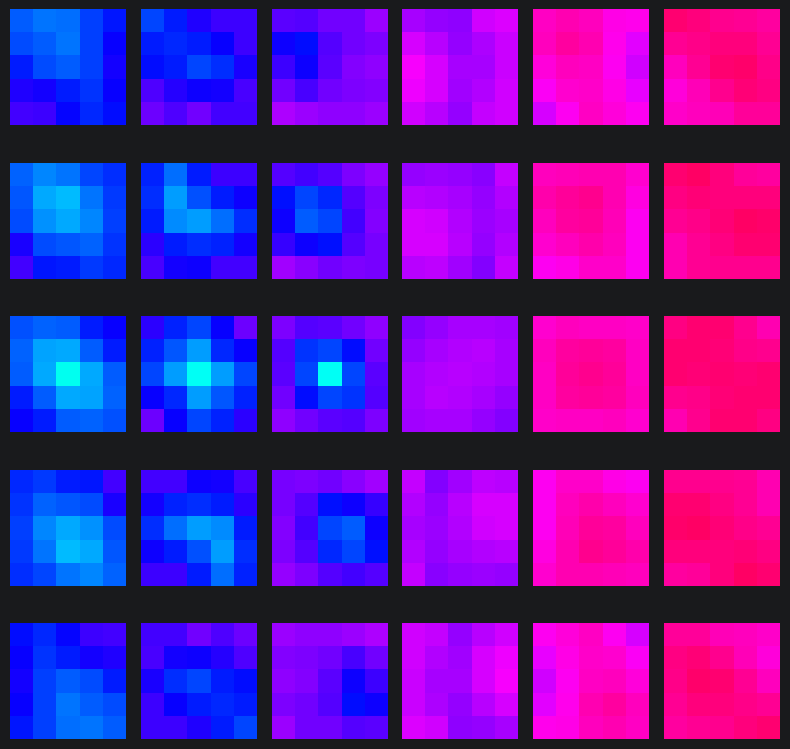

In [14]:
vis(X_train[0])

In [43]:
# features compression

def extract_features(X):
    means = X.mean(axis=(1, 2, 3))

    stds = X.std(axis=(1, 2, 3))

    maxs = X.max(axis=(1, 2, 3))

    return np.concatenate(
        [means, stds, maxs],
        axis=1
    )

array([[10.56913659, 13.50637339, 18.13327141, ..., 27.34761304,
        33.73502734, 35.6443389 ],
       [10.2858455 , 11.39583482, 14.09552744, ..., 26.28984671,
        27.20262709, 30.76731582],
       [12.50120805, 16.22172238, 22.68071355, ..., 35.37403749,
        39.921951  , 41.1589297 ],
       ...,
       [16.15444031, 20.19825475, 30.76476467, ..., 55.08581794,
        55.33949196, 55.56957111],
       [13.12645707, 17.66809648, 26.8191148 , ..., 41.84598196,
        43.43014635, 46.1877266 ],
       [ 6.42096438,  8.13280846, 12.25376162, ..., 21.01944682,
        24.51007822, 28.76068891]], shape=(2024, 18))

In [44]:
# Result evaluation / writing predictions

def test_solution(X_train, y_train, X_val, y_val, feature_num=0):
    assert X_train.shape[-1] <= 300, "Too many features! Should be less than 300"
    assert X_val.shape[-1] <= 300, "Too many features! Should be less than 300"

    model =  LinearRegression().fit(
        X_train,
        y_train[:, feature_num]
    )
    predictions = model.predict(X_val)
    rmse = mean_squared_error(
        predictions,
        y_val[:, feature_num]
    )**.5
    normalized_rmse = rmse * SCALING_WEIGHTS[feature_num]
    print(f"Property #{feature_num}:    raw RMSE={rmse:.6f}")
    print(f"Property #{feature_num}: scaled RMSE={normalized_rmse:.6f}")
    return round(normalized_rmse, 6)

In [46]:
def dummy_feature_extractor(X):
    X_new = X.reshape((X.shape[0], -1)) # ravel
    X_new = X_new[:, :300] # pick first 300 features
    return X_new

dummy_feature_extractor(X_train).shape

(2024, 18)

In [51]:
%%time
total_score = 0
for feature_number in range(3):
  total_score += test_solution(
      dummy_feature_extractor(X_train),
      y_train,
      dummy_feature_extractor(X_val),
      y_val,
      feature_num=feature_number
  )
  print()
total_score /= 3
print('='*16)
print(f"Total score = {total_score:.6f}")


Property #0:    raw RMSE=1.006342
Property #0: scaled RMSE=6.708946

Property #1:    raw RMSE=0.773304
Property #1: scaled RMSE=9.666301

Property #2:    raw RMSE=1.617753
Property #2: scaled RMSE=1.617753

Total score = 5.997667
CPU times: user 231 ms, sys: 47 μs, total: 231 ms
Wall time: 64 ms


In [19]:
# Prepare Answers

def generate_predictions(X_train, y_train, X_test, feature_num=0):
    assert X_train.shape[-1] <= 300
    assert X_test.shape[-1] <= 300

    model = LinearRegression().fit(
        X_train,
        y_train[:, feature_num]
    )
    predictions = model.predict(X_test)
    return predictions


## Generate solutions and write to the file
combined = {'ID': np.arange(X_test.shape[0])}

for feature_number in range(3):
    predictions = generate_predictions(
        dummy_feature_extractor(X_train),
        y_train,
        dummy_feature_extractor(X_test),
        feature_num=feature_number
    )

    combined[f'y{feature_number+1}'] = predictions

pd.DataFrame(combined).to_csv('predictions.csv', index=False)

In [24]:
# load the test dataset
loaded = pd.read_pickle("./Solution/test_set/ml_data_onsite_final_test.pickle")
X_test_final = loaded['X']['final_test']


# make final predictions
combined = {'ID': np.arange(X_test_final.shape[0])}

for feature_number in range(3):
    predictions = generate_predictions(
        dummy_feature_extractor(X_train),
        y_train,
        dummy_feature_extractor(X_test_final),
        feature_num=feature_number
    )

    combined[f'y{feature_number+1}'] = predictions

pd.DataFrame(combined).to_csv('final_predictions.csv', index=False)